In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ecc_vr as vr 

from Sphere_Ellipsoid_Utils import unif_hypersphere, unif_hyperellipsoid, unit_ball_volume, scale_axes_target_volume, simulate_edge_curves

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [ ]:
def count_triangles(X: np.ndarray, t: float) -> int:
    X = np.asarray(X, dtype=float)

    n, d = X.shape

    epsilon = t / (n ** (1 / (d - 1)))

    D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2) # distance matrix

    A = (D <= epsilon).astype(int) # creates adjacency matrix A where A[i,j] = 1 if points i and j are within epsilon distance otherwise A[i,j] = 0
    np.fill_diagonal(A, 0) # sets diagonal entries to 0

    A3 = A @ A @ A # entries of A^3 count the number of walks of length 3 between vertices
    
    # adds up diagonal entries of A^3 which counts all length-3 closed walks
    triangles = np.trace(A3) // 6 # divide by 6 since each triangle is counted 6 times (3 choices of starting vertex and 2 directions around the triangle)

    return int(triangles)

def triangle_count_curve(X: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    return np.array([count_triangles(X, float(t)) for t in t_grid], dtype=float)

def simulate_triangle_curves(point_cloud_sampler, n_resamples, t_grid, seed):
    rng = np.random.default_rng(seed)
    curves = np.empty((n_resamples, len(t_grid)), dtype=float)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))
        X = point_cloud_sampler(sample_seed)
        curves[i] = triangle_count_curve(X, t_grid)

    return curves

In [12]:
def sphere_vs_ellipsoid_edge_curve_classifier(
        n_points: int = 100,
        t_grid: np.ndarray | None = None,
        n_resamples: int = 300,
        ambient_dim: int | None = None,
        ellipsoid_stretch: np.ndarray | list | tuple | None = None,
        target_volume: float = 1.0,
        seed1: int = 42,
        seed2: int = 43,
        test_size: float = 0.25,
        random_state: int = 0,
):  
    
    if t_grid is None:
        t_grid = np.linspace(0.5, 5, 30)
    else:
        t_grid = np.asarray(t_grid, dtype = float)

    if ellipsoid_stretch is None:
        ambient_dim = 3 if ambient_dim is None else ambient_dim
        ellipsoid_stretch = np.ones(ambient_dim, dtype = float)
        ellipsoid_stretch[0] = 1.5
    else:
        ellipsoid_stretch = np.asarray(ellipsoid_stretch, dtype = float)
        if ambient_dim is None:
            ambient_dim = ellipsoid_stretch.size
            raise ValueError("ambient_dim must match len(ellipsoid_stretch).")
    
    target_volume = unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch)
    
    sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** ( 1.0 / ambient_dim)
    ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume)

    curves_sphere = simulate_edge_curves(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed = seed1,
    )
    
    curves_ellipsoid = simulate_edge_curves(
        point_cloud_sampler=lambda s: unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed=seed2,
    )

    X = np.vstack([curves_sphere, curves_ellipsoid])
    y = np.array([0] * len(curves_sphere) + [1] * len(curves_ellipsoid))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = test_size,
        random_state=random_state,
        stratify=y
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter = 5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": "sphere",
        "shape2": "ellipsoid",
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "sphere_radius": sphere_radius,
        "ellipsoid_stretch_input": np.asarray(ellipsoid_stretch, dtype = float),
        "ellipsoid_axes": ellipsoid_axes,
        "t_grid": t_grid,
        "curves1": curves_sphere,
        "curves2": curves_ellipsoid,
        "curves_sphere": curves_sphere,
        "curves_ellipsoid": curves_ellipsoid,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=["Sphere", "Ellipsoid"],
            zero_division=0,
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }

In [13]:
def sphere_vs_ellipsoid_triangle_curve_classifier(
        n_points: int = 100,
        t_grid: np.ndarray | None = None,
        n_resamples: int = 300,
        ambient_dim: int | None = None,
        ellipsoid_stretch: np.ndarray | list | tuple | None = None,
        target_volume: float = 1.0,
        seed1: int = 42,
        seed2: int = 43,
        test_size: float = 0.25,
        random_state: int = 0,
):  

    if t_grid is None:
        t_grid = np.linspace(0.5, 5, 30)
    else:
        t_grid = np.asarray(t_grid, dtype=float)

    if ellipsoid_stretch is None:
        ambient_dim = 3 if ambient_dim is None else ambient_dim
        ellipsoid_stretch = np.ones(ambient_dim, dtype=float)
        ellipsoid_stretch[0] = 1.5
    else:
        ellipsoid_stretch = np.asarray(ellipsoid_stretch, dtype=float)
        if ambient_dim is None:
            ambient_dim = ellipsoid_stretch.size

    target_volume = unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch)
    
    sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** (1.0 / ambient_dim)
    ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume)

    #  Same as our edge function excpet using triangles
    curves_sphere = simulate_triangle_curves(
        point_cloud_sampler=lambda s: unif_hypersphere(
            n_points=n_points,
            d=ambient_dim,
            r=sphere_radius,
            seed=s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed=seed1,
    )
    
    curves_ellipsoid = simulate_triangle_curves(
        point_cloud_sampler=lambda s: unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed=s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed=seed2,
    )

    X = np.vstack([curves_sphere, curves_ellipsoid])
    y = np.array([0] * len(curves_sphere) + [1] * len(curves_ellipsoid))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": "sphere",
        "shape2": "ellipsoid",
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "sphere_radius": sphere_radius,
        "ellipsoid_stretch_input": np.asarray(ellipsoid_stretch, dtype = float),
        "ellipsoid_axes": ellipsoid_axes,
        "t_grid": t_grid,
        "curves1": curves_sphere,
        "curves2": curves_ellipsoid,
        "curves_sphere": curves_sphere,
        "curves_ellipsoid": curves_ellipsoid,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=["Sphere", "Ellipsoid"],
            zero_division=0,
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }

In [14]:
def plot_sphere_ellipsoid_results(result, curve_type="edge"):
    t_grid = result["t_grid"]
    curves_sphere = result["curves_sphere"]
    curves_ellipsoid = result["curves_ellipsoid"]

    mean1 = curves_sphere.mean(axis=0)
    sd1 = curves_sphere.std(axis=0, ddof=1)

    mean2 = curves_ellipsoid.mean(axis=0)
    sd2 = curves_ellipsoid.std(axis=0, ddof=1)

    # clean labels
    curve_name = curve_type.capitalize()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    # Sphere
    ax[0].plot(
        t_grid,
        mean1,
        lw=2,
        label=f"Sphere {curve_name} Count Mean"
    )
    ax[0].fill_between(
        t_grid,
        mean1 - sd1,
        mean1 + sd1,
        alpha=0.2
    )

    # Ellipsoid
    ax[0].plot(
        t_grid,
        mean2,
        lw=2,
        label=f"Ellipsoid {curve_name} Count Mean"
    )
    ax[0].fill_between(
        t_grid,
        mean2 - sd2,
        mean2 + sd2,
        alpha=0.2
    )

    ax[0].set_xlabel("t")
    ax[0].set_ylabel(f"{curve_name} Count")
    ax[0].set_title(f"{curve_name} Count Curves")
    ax[0].legend()

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        display_labels=["Sphere", "Ellipsoid"],
        cmap="Blues",
        ax=ax[1],
    )

    ax[1].set_title(f"{curve_name} Classifier Confusion Matrix")

    plt.tight_layout()
    plt.show()

    print(f"{curve_name} Classification Accuracy:", result["accuracy"])
    print(result["report"])

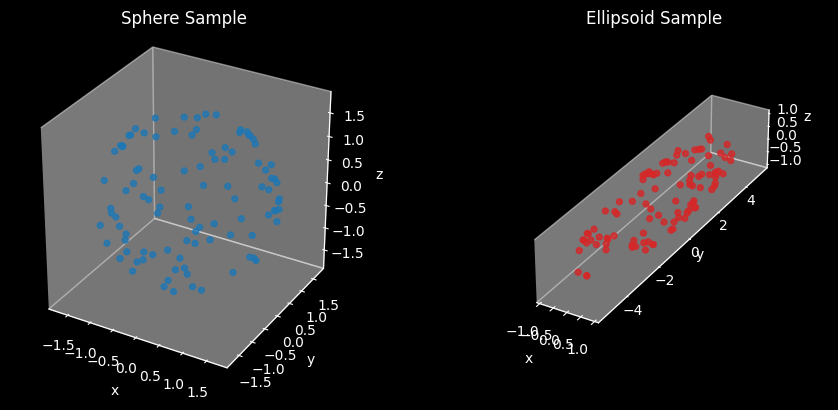

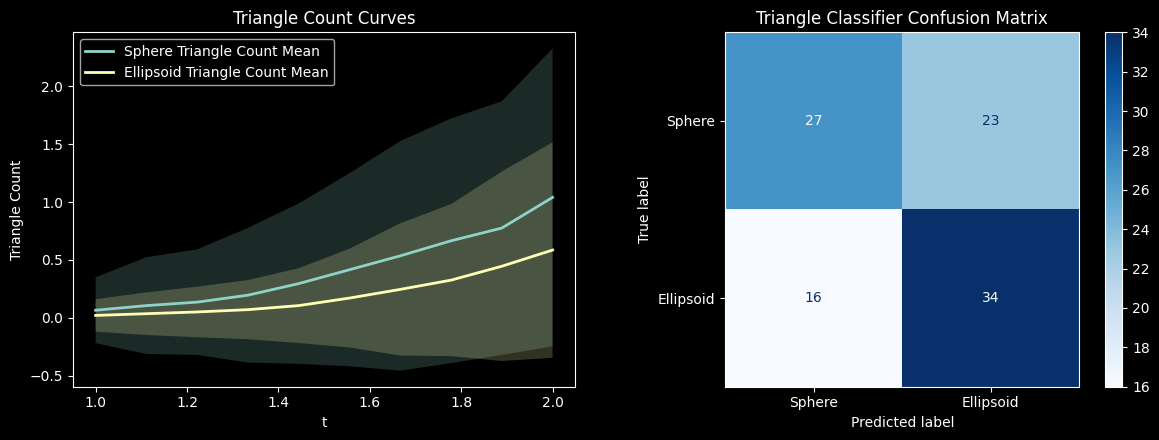

Triangle Classification Accuracy: 0.61
              precision    recall  f1-score   support

      Sphere       0.63      0.54      0.58        50
   Ellipsoid       0.60      0.68      0.64        50

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100



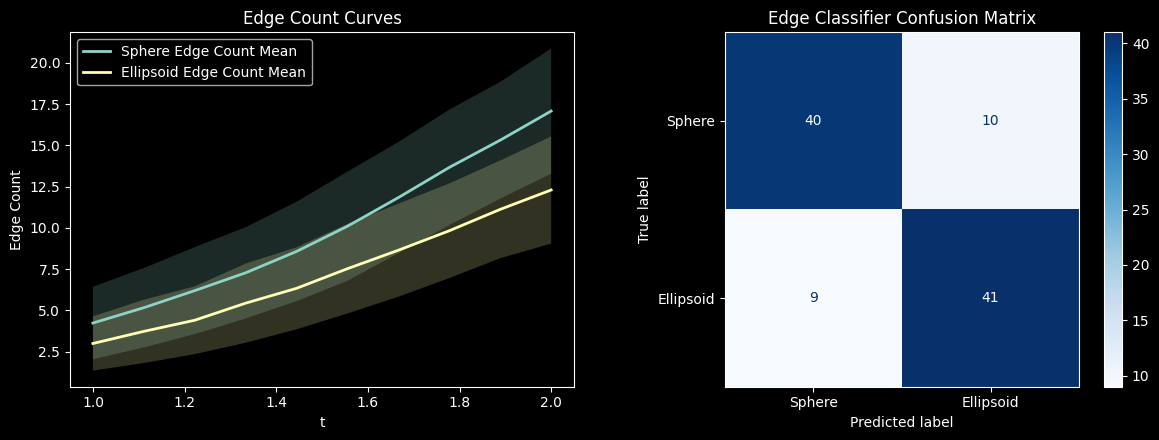

Edge Classification Accuracy: 0.81
              precision    recall  f1-score   support

      Sphere       0.82      0.80      0.81        50
   Ellipsoid       0.80      0.82      0.81        50

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



In [25]:
plt.style.use("dark_background")

# INPUT
n_points = 100
n_resamples = 200
ambient_dim = 3
t_grid = np.linspace(1,2,10)
ellipsoid_stretch = [1.0, 5.0,1]

result = sphere_vs_ellipsoid_triangle_curve_classifier(
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    ellipsoid_stretch=ellipsoid_stretch,
)

result2 = sphere_vs_ellipsoid_edge_curve_classifier(
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    ellipsoid_stretch=ellipsoid_stretch,
)


fig = plt.figure(figsize=(10, 4))

samples = [
    ("Sphere", unif_hypersphere(n_points, result["ambient_dim"], r = result["sphere_radius"], seed = 123), "tab:blue"),
    ("Ellipsoid", unif_hyperellipsoid(n_points, result["ellipsoid_axes"], seed = 456), "tab:red"),
]

for i, (shape, X, color) in enumerate(samples, start = 1):
    projected = X.shape[1] > 3
    if projected:
        X = vr.pca_project(X, out_dim = 2)
    
    d = X.shape[1]
    ax = fig.add_subplot(1, 2, i, projection="3d" if d == 3 else None)

    if d == 3:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 18, alpha = 0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    elif d == 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8, color=color)
        ax.set_aspect("equal")
        ax.set_aspect("equal")
        ax.set_xlabel("PC1" if projected else "x")
        ax.set_ylabel("PC2" if projected else "y")
    else:
        ax.scatter(X[:, 0], np.zeros(len(X)), s=18, alpha=0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("")

    ax.set_title(f"{shape} Sample")
    ax.grid(False)

plt.tight_layout()
plt.show()

plot_sphere_ellipsoid_results(result,curve_type="triangle")
plot_sphere_ellipsoid_results(result2, curve_type="edge")

In [17]:
def compare_edge_triangle_classifiers(
    n_points_list,
    t_grid_list,
    ambient_dim=2,
    ellipsoid_stretch=(1.0, 5.0),
    n_resamples=100,
    n_repeats=5,
):
    results = []

    for n_points in n_points_list:
        for t_grid in t_grid_list:

            edge_acc = []
            triangle_acc = []

            for r in range(n_repeats):

                edge_result = sphere_vs_ellipsoid_edge_curve_classifier(
                    ambient_dim=ambient_dim,
                    n_points=n_points,
                    n_resamples=n_resamples,
                    t_grid=t_grid,
                    ellipsoid_stretch=ellipsoid_stretch,
                    seed1=1000 + r,
                    seed2=2000 + r,
                    random_state=r,
                )

                triangle_result = sphere_vs_ellipsoid_triangle_curve_classifier(
                    ambient_dim=ambient_dim,
                    n_points=n_points,
                    n_resamples=n_resamples,
                    t_grid=t_grid,
                    ellipsoid_stretch=ellipsoid_stretch,
                    seed1=3000 + r,
                    seed2=4000 + r,
                    random_state=r,
                )

                edge_acc.append(edge_result["accuracy"])
                triangle_acc.append(triangle_result["accuracy"])

            edge_acc = np.asarray(edge_acc)
            triangle_acc = np.asarray(triangle_acc)

            results.append({
                "n_points": n_points,
                "t_min": float(t_grid.min()),
                "t_max": float(t_grid.max()),
                "n_t": len(t_grid),

                "edge_mean": edge_acc.mean(),
                "edge_sd": edge_acc.std(ddof=1),

                "triangle_mean": triangle_acc.mean(),
                "triangle_sd": triangle_acc.std(ddof=1),

                "difference": triangle_acc.mean() - edge_acc.mean(),
            })

    return results

In [18]:
def plot_edge_triangle_comparison(results):

    labels = []
    edge_means = []
    triangle_means = []

    for r in results:

        label = (
            f"n={r['n_points']}\n"
            f"t∈[{r['t_min']:.1f},{r['t_max']:.1f}]"
        )

        labels.append(label)

        edge_means.append(r["edge_mean"])
        triangle_means.append(r["triangle_mean"])

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(12, 5))

    plt.bar(x - width/2, edge_means, width, label="Edge")
    plt.bar(x + width/2, triangle_means, width, label="Triangle")

    plt.xticks(x, labels)
    plt.ylabel("Mean Classification Accuracy")
    plt.title("Edge vs Triangle Curve Classification")
    plt.ylim(0, 1.05)

    plt.legend()
    plt.tight_layout()
    plt.show()

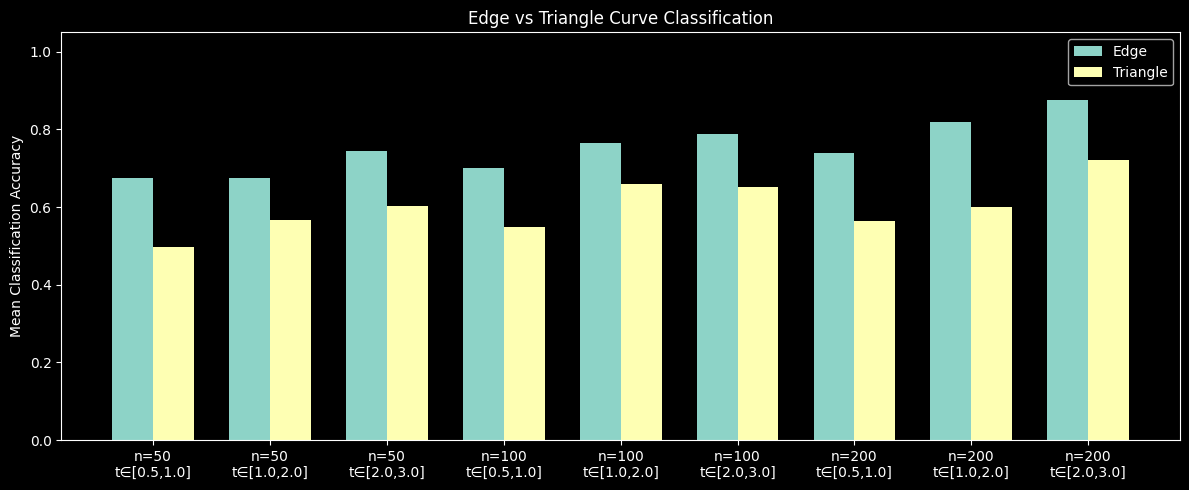

{'n_points': 50, 't_min': 0.5, 't_max': 1.0, 'n_t': 10, 'edge_mean': np.float64(0.6759999999999999), 'edge_sd': np.float64(0.08173126696681021), 'triangle_mean': np.float64(0.496), 'triangle_sd': np.float64(0.043358966777357615), 'difference': np.float64(-0.17999999999999994)}
{'n_points': 50, 't_min': 1.0, 't_max': 2.0, 'n_t': 10, 'edge_mean': np.float64(0.6759999999999999), 'edge_sd': np.float64(0.05366563145999494), 'triangle_mean': np.float64(0.5680000000000001), 'triangle_sd': np.float64(0.05019960159204452), 'difference': np.float64(-0.10799999999999987)}
{'n_points': 50, 't_min': 2.0, 't_max': 3.0, 'n_t': 10, 'edge_mean': np.float64(0.744), 'edge_sd': np.float64(0.06542170893518448), 'triangle_mean': np.float64(0.6040000000000001), 'triangle_sd': np.float64(0.05549774770204643), 'difference': np.float64(-0.1399999999999999)}
{'n_points': 100, 't_min': 0.5, 't_max': 1.0, 'n_t': 10, 'edge_mean': np.float64(0.7), 'edge_sd': np.float64(0.08246211251235319), 'triangle_mean': np.float

In [ ]:
results = compare_edge_triangle_classifiers(
    n_points_list=[50, 100, 200],
    t_grid_list=[
        np.linspace(0.5, 1.0, 10),
        np.linspace(1.0, 2.0, 10),
        np.linspace(2.0, 3.0, 10),
    ],
    ambient_dim=2,
    ellipsoid_stretch=(1.0, 5.0),
    n_resamples=100,
    n_repeats=5,
)

plot_edge_triangle_comparison(results)

for r in results:
    print(r)

In [26]:
def find_stretch_thresholds(
    classifier_fn,
    curve_type="edge",
    ambient_dim=3,
    n_points=100,
    n_resamples=100,
    t_grid=None,
    stretch_min=1.0,
    stretch_max=5.0,
    n_stretches=21,
    n_repeats=10,
    targets=(0.70, 0.80, 0.90),
):

    if t_grid is None:
        t_grid = np.linspace(0.5, 3.0, 15)

    stretch_values = np.linspace(stretch_min, stretch_max, n_stretches)

    mean_acc = []
    sd_acc = []
    all_acc = []

    for s in stretch_values:

        run_acc = []

        for r in range(n_repeats):

            ellipsoid_stretch = np.array([s, 1.0, 1.0], dtype=float)

            if ambient_dim == 2:
                ellipsoid_stretch = ellipsoid_stretch[:2]

            elif ambient_dim > 3:
                ellipsoid_stretch = np.concatenate(
                    [ellipsoid_stretch, np.ones(ambient_dim - 3)]
                )

            result = classifier_fn(
                ambient_dim=ambient_dim,
                n_points=n_points,
                n_resamples=n_resamples,
                t_grid=t_grid,
                ellipsoid_stretch=ellipsoid_stretch,
                seed1=1000 + r,
                seed2=2000 + r,
                random_state=r,
            )

            run_acc.append(result["accuracy"])

        run_acc = np.asarray(run_acc, dtype=float)

        all_acc.append(run_acc)
        mean_acc.append(run_acc.mean())
        sd_acc.append(run_acc.std(ddof=1))

    mean_acc = np.asarray(mean_acc)
    sd_acc = np.asarray(sd_acc)

    thresholds = {}

    for target in targets:
        good = np.where(mean_acc >= target)[0]

        thresholds[target] = (
            None if len(good) == 0 else stretch_values[good[0]]
        )

    return {
        "curve_type": curve_type,
        "stretch_values": stretch_values,
        "mean_acc": mean_acc,
        "sd_acc": sd_acc,
        "all_acc": all_acc,
        "thresholds": thresholds,
        "targets": tuple(targets),
        "ambient_dim": ambient_dim,
        "n_points": n_points,
        "n_resamples": n_resamples,
        "n_repeats": n_repeats,
        "t_grid": np.asarray(t_grid, dtype=float),
    }

In [28]:
def plot_stretch_threshold_search(summary):

    stretch_values = summary["stretch_values"]
    mean_acc = summary["mean_acc"]
    sd_acc = summary["sd_acc"]
    thresholds = summary["thresholds"]

    curve_type = summary.get("curve_type", "edge").capitalize()

    plt.style.use("default")

    plt.figure(figsize=(7, 4))

    plt.plot(
        stretch_values,
        mean_acc,
        marker="o",
        lw=2,
        color="tab:blue",
    )

    plt.fill_between(
        stretch_values,
        mean_acc - sd_acc,
        mean_acc + sd_acc,
        alpha=0.2,
        color="tab:blue",
    )

    colors = {
        0.80: "tab:green",
        0.90: "tab:red",
        0.95: "tab:orange",
    }

    for target, stretch in thresholds.items():

        plt.axhline(
            target,
            ls="--",
            color=colors.get(target, "gray"),
            alpha=0.8,
        )

        if stretch is not None:
            plt.axvline(
                stretch,
                ls=":",
                color=colors.get(target, "gray"),
                alpha=0.8,
            )

    plt.xlabel("Stretch factor on first axis")
    plt.ylabel("Classification accuracy")

    plt.title(
        f"{curve_type} Curve Stretch Threshold Search"
    )

    plt.ylim(0, 1.05)

    plt.grid(True, alpha=0.3)

    plt.show()

    for target, stretch in thresholds.items():

        if stretch is None:
            print(f"No tested stretch reached {target:.0%} accuracy.")

        else:
            print(
                f"Smallest tested stretch reaching "
                f"{target:.0%} accuracy: {stretch:.3f}"
            )

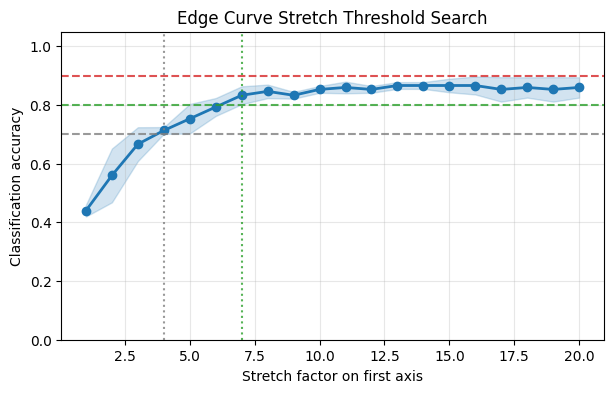

Smallest tested stretch reaching 70% accuracy: 4.000
Smallest tested stretch reaching 80% accuracy: 7.000
No tested stretch reached 90% accuracy.


In [29]:
edge_summary = find_stretch_thresholds(
    classifier_fn=sphere_vs_ellipsoid_edge_curve_classifier,
    curve_type="edge",
    ambient_dim=2,
    n_points=100,
    n_resamples=100,
    t_grid=np.linspace(1, 2, 10),
    stretch_min=1.0,
    stretch_max=20.0,
    n_stretches=20,
    n_repeats=3,
)

plot_stretch_threshold_search(edge_summary)

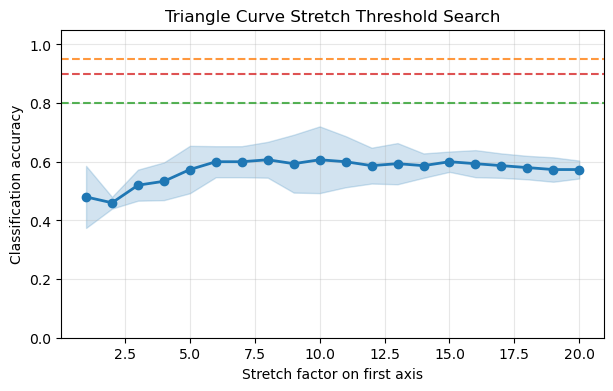

No tested stretch reached 80% accuracy.
No tested stretch reached 90% accuracy.
No tested stretch reached 95% accuracy.


In [ ]:
triangle_summary = find_stretch_thresholds(
    classifier_fn=sphere_vs_ellipsoid_triangle_curve_classifier,
    curve_type="triangle",
    ambient_dim=2,
    n_points=100,
    n_resamples=100,
    t_grid=np.linspace(1, 2, 10),
    stretch_min=1.0,
    stretch_max=20.0,
    n_stretches=20,
    n_repeats=3,
)

plot_stretch_threshold_search(triangle_summary)

In [ ]:
def compare_stretch_patterns(
    classifier_fn,
    curve_type,
    patterns,
    stretch_values,
    ambient_dim=3,
    n_points=100,
    n_resamples=100,
    t_grid=None,
    n_repeats=5,
):

    if t_grid is None:
        t_grid = np.linspace(0.5, 3.0, 15)
    else:
        t_grid = np.asarray(t_grid, dtype=float)

    stretch_values = np.asarray(stretch_values, dtype=float)

    summary = {}

    for name, pattern_fn in patterns.items():

        mean_acc = []
        sd_acc = []
        all_acc = []

        for s in stretch_values:

            run_acc = []

            for r in range(n_repeats):

                ellipsoid_stretch = np.asarray(
                    pattern_fn(s, ambient_dim),
                    dtype=float
                )

                if ellipsoid_stretch.shape != (ambient_dim,):
                    raise ValueError(
                        f"Pattern {name!r} returned shape "
                        f"{ellipsoid_stretch.shape}, "
                        f"expected {(ambient_dim,)}"
                    )

                result = classifier_fn(
                    ambient_dim=ambient_dim,
                    n_points=n_points,
                    n_resamples=n_resamples,
                    t_grid=t_grid,
                    ellipsoid_stretch=ellipsoid_stretch,
                    seed1=1000 + r,
                    seed2=2000 + r,
                    random_state=r,
                )

                run_acc.append(result["accuracy"])

            run_acc = np.asarray(run_acc, dtype=float)

            all_acc.append(run_acc)

            mean_acc.append(run_acc.mean())

            sd_acc.append(
                run_acc.std(ddof=1)
                if len(run_acc) > 1 else 0.0
            )

        summary[name] = {
            "mean_acc": np.asarray(mean_acc),
            "sd_acc": np.asarray(sd_acc),
            "all_acc": all_acc,
        }

    return {
        "curve_type": curve_type,
        "patterns": patterns,
        "stretch_values": stretch_values,
        "summary": summary,
        "ambient_dim": ambient_dim,
        "n_points": n_points,
        "n_resamples": n_resamples,
        "n_repeats": n_repeats,
        "t_grid": t_grid,
    }

In [ ]:
def plot_stretch_pattern_comparison(
    results,
    accuracy_target=None,
):

    stretch_values = results["stretch_values"]
    summary = results["summary"]

    ambient_dim = results["ambient_dim"]

    curve_type = results.get(
        "curve_type",
        "edge"
    ).capitalize()

    plt.style.use("default")

    plt.figure(figsize=(8, 5))

    for name, vals in summary.items():

        mean_acc = vals["mean_acc"]
        sd_acc = vals["sd_acc"]

        plt.plot(
            stretch_values,
            mean_acc,
            marker="o",
            lw=2,
            label=name,
        )

        plt.fill_between(
            stretch_values,
            mean_acc - sd_acc,
            mean_acc + sd_acc,
            alpha=0.15,
        )

    if accuracy_target is not None:

        plt.axhline(
            accuracy_target,
            ls="--",
            color="tab:red",
            label=f"{accuracy_target:.0%} target",
        )

    plt.xlabel("Stretch parameter s")

    plt.ylabel("Classification accuracy")

    plt.title(
        f"{curve_type} Curve Stretch Pattern Comparison "
        f"in {ambient_dim}D"
    )

    plt.ylim(0, 1.05)

    plt.grid(True, alpha=0.3)

    plt.legend()

    plt.show()

    for name, vals in summary.items():

        mean_acc = vals["mean_acc"]
        sd_acc = vals["sd_acc"]

        print(name)

        for s, acc, sd in zip(
            stretch_values,
            mean_acc,
            sd_acc,
        ):
            print(
                f"  s={s:.3f}   "
                f"mean_acc={acc:.3f}   "
                f"sd={sd:.3f}"
            )

        if accuracy_target is not None:

            good = np.where(mean_acc >= accuracy_target)[0]

            if len(good) > 0:

                print(
                    f"  first stretch reaching "
                    f"{accuracy_target:.0%}: "
                    f"{stretch_values[good[0]]:.3f}"
                )

            else:
                print(
                    f"  no tested stretch reached "
                    f"{accuracy_target:.0%}"
                )

        print()

In [ ]:
ambient_dim = 2
stretch_values = np.linspace(1.0, 10.0, 10)

if ambient_dim == 2:
    patterns = {
        "[s, 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }

elif ambient_dim == 3:
    patterns = {
        "[s, 1, 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s, 1]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s, 1]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }

else:
    patterns = {
        "[s, 1, 1, ..., 1]": lambda s, d: [s] + [1.0] * (d - 1),
        "[s, s, 1, ..., 1]": lambda s, d: [s, s] + [1.0] * (d - 2),
        "[s, 1/s, 1, ..., 1]": lambda s, d: [s, 1.0 / s] + [1.0] * (d - 2),
    }

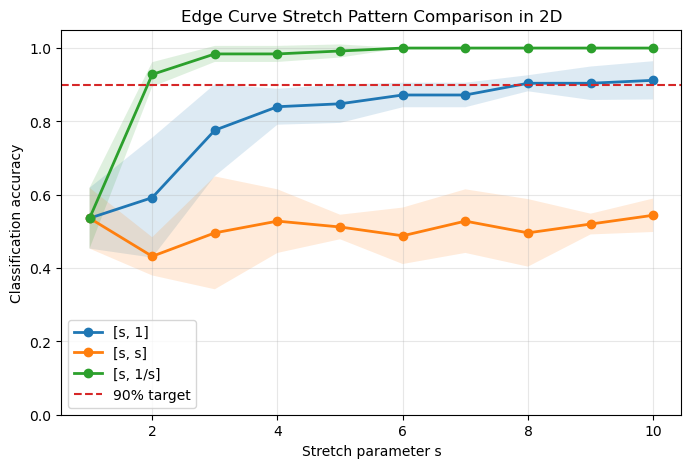

[s, 1]
  s=1.000   mean_acc=0.536   sd=0.083
  s=2.000   mean_acc=0.592   sd=0.163
  s=3.000   mean_acc=0.776   sd=0.125
  s=4.000   mean_acc=0.840   sd=0.049
  s=5.000   mean_acc=0.848   sd=0.052
  s=6.000   mean_acc=0.872   sd=0.033
  s=7.000   mean_acc=0.872   sd=0.033
  s=8.000   mean_acc=0.904   sd=0.022
  s=9.000   mean_acc=0.904   sd=0.046
  s=10.000   mean_acc=0.912   sd=0.052
  first stretch reaching 90%: 8.000

[s, s]
  s=1.000   mean_acc=0.536   sd=0.083
  s=2.000   mean_acc=0.432   sd=0.052
  s=3.000   mean_acc=0.496   sd=0.154
  s=4.000   mean_acc=0.528   sd=0.087
  s=5.000   mean_acc=0.512   sd=0.033
  s=6.000   mean_acc=0.488   sd=0.077
  s=7.000   mean_acc=0.528   sd=0.087
  s=8.000   mean_acc=0.496   sd=0.092
  s=9.000   mean_acc=0.520   sd=0.028
  s=10.000   mean_acc=0.544   sd=0.046
  no tested stretch reached 90%

[s, 1/s]
  s=1.000   mean_acc=0.536   sd=0.083
  s=2.000   mean_acc=0.928   sd=0.033
  s=3.000   mean_acc=0.984   sd=0.022
  s=4.000   mean_acc=0.984   sd

In [ ]:
edge_results = compare_stretch_patterns(
    classifier_fn=sphere_vs_ellipsoid_edge_curve_classifier,
    curve_type="edge",
    patterns=patterns,
    stretch_values=stretch_values,
    ambient_dim=ambient_dim,
    n_points=200,
    n_resamples=50,
    t_grid=np.linspace(1.0, 2.0, 5),
    n_repeats=5,
)

plot_stretch_pattern_comparison(
    edge_results,
    accuracy_target=0.90,
)

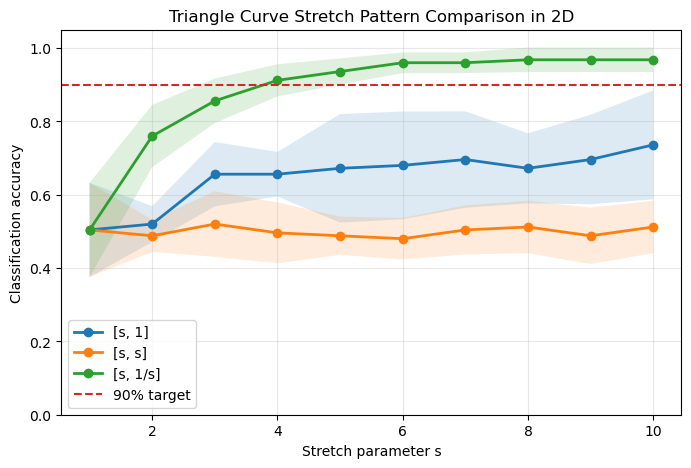

[s, 1]
  s=1.000   mean_acc=0.504   sd=0.128
  s=2.000   mean_acc=0.520   sd=0.049
  s=3.000   mean_acc=0.656   sd=0.088
  s=4.000   mean_acc=0.656   sd=0.061
  s=5.000   mean_acc=0.672   sd=0.148
  s=6.000   mean_acc=0.680   sd=0.147
  s=7.000   mean_acc=0.696   sd=0.131
  s=8.000   mean_acc=0.672   sd=0.095
  s=9.000   mean_acc=0.696   sd=0.122
  s=10.000   mean_acc=0.736   sd=0.149
  no tested stretch reached 90%

[s, s]
  s=1.000   mean_acc=0.504   sd=0.128
  s=2.000   mean_acc=0.488   sd=0.044
  s=3.000   mean_acc=0.520   sd=0.089
  s=4.000   mean_acc=0.496   sd=0.083
  s=5.000   mean_acc=0.488   sd=0.052
  s=6.000   mean_acc=0.480   sd=0.057
  s=7.000   mean_acc=0.504   sd=0.067
  s=8.000   mean_acc=0.512   sd=0.072
  s=9.000   mean_acc=0.488   sd=0.077
  s=10.000   mean_acc=0.512   sd=0.072
  no tested stretch reached 90%

[s, 1/s]
  s=1.000   mean_acc=0.504   sd=0.128
  s=2.000   mean_acc=0.760   sd=0.085
  s=3.000   mean_acc=0.856   sd=0.061
  s=4.000   mean_acc=0.912   sd=0.0

In [ ]:
edge_results = compare_stretch_patterns(
    classifier_fn=sphere_vs_ellipsoid_triangle_curve_classifier,
    curve_type="triangle",
    patterns=patterns,
    stretch_values=stretch_values,
    ambient_dim=ambient_dim,
    n_points=200,
    n_resamples=50,
    t_grid=np.linspace(1.0, 2.0, 5),
    n_repeats=5,
)

plot_stretch_pattern_comparison(
    edge_results,
    accuracy_target=0.90,
)